In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [25]:
from cns.process.breakpoints import make_breaks
from cns.data_utils import load_COSMIC
import random
import numpy as np

cosmic_genes = load_COSMIC()
cosmic_genes.head()

_, start, end = make_breaks("arms")["chr3"]
gene_start, gene_end = cosmic_genes.query("gene == 'SOX2'")[["start", "end"]].values.tolist()[0]

In [26]:
# Initialize a list to store the ranges
ranges = []

reps = 10

# Repeat until 8 ranges are sampled
while len(ranges) < 6 * reps:
    # Generate a random range
    rand_start = random.randint(start, end)
    rand_end = random.randint(rand_start, end)

    # Check if the range contains gene_start and gene_end
    if rand_start <= gene_start and rand_end >= gene_end:
        # If it does, add it to the list
        ranges.append((rand_start, rand_end))

In [27]:
breaks = np.array(ranges).flatten()
breaks.sort()
split_ranges = []

for start, end in ranges:
    current_start = start

    for brk in breaks:
        if start < brk < end:
            split_ranges.append((current_start, brk))
            current_start = brk

    split_ranges.append((current_start, end))

In [28]:
import pandas as pd

# Count the occurrences of each pair
counts = pd.Series(split_ranges).value_counts().reset_index()

# Rename the columns
counts.columns = ['range', 'CN']

# Split the range into start and end
counts[['start', 'end']] = pd.DataFrame(counts['range'].tolist(), index=counts.index)

# Drop the 'range' column
counts = counts.drop('range', axis=1)

# Reorder the columns
counts = counts[['start', 'end', 'CN']].sort_values(by=['start'], ignore_index=True)
counts["CN"] = counts["CN"] / reps + 2
counts.head()

,start,end,CN
0,94841174,99613590,2.1
1,99613590,101033544,2.2
2,101033544,102009121,2.3
3,102009121,104161738,2.4
4,104161738,108101997,2.5


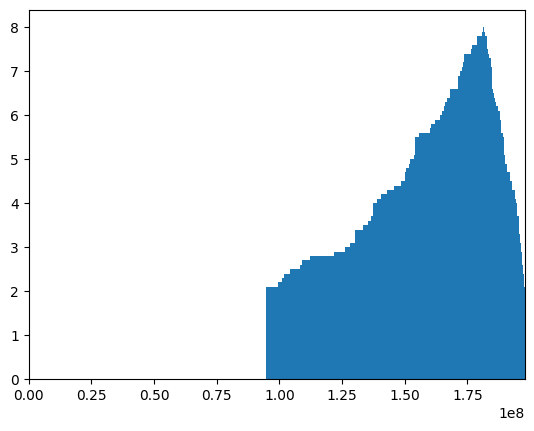

In [29]:
import matplotlib.pyplot as plt

# Calculate the widths of the bars
widths = counts['end'] - counts['start']

# Create a bar plot
plt.bar(x=counts['start'], height=counts['CN'], width=widths, align='edge')

# Set the x-axis start to 0
plt.xlim(0, max(counts['end']))

# Display the plot
plt.show()

In [73]:
from cns.data_utils import load_merged_samples, load_merged_cns, get_cns_for_type

samples = load_merged_samples().query("type == 'LUSC'")
cns = load_merged_cns(samples)
data_chrom3 = cns.query("chrom == 'chr3'")

In [79]:
from cns.process.breakpoints import get_breaks
data_breaks = get_breaks(data_chrom3)

In [80]:
from cns.process.binning import bin_by_breaks

binned_data = bin_by_breaks(data_chrom3, data_breaks, print_progress=True)

Binning chr (853/853)


In [81]:
from cns.process.binning import group_bins, add_cns_loc

groups = group_bins(add_cns_loc(binned_data))

In [82]:
groups

,cum_mid,chrom,start,end,mid,length,major_cn,minor_cn,total_cn
0,492498232,chr3,0,96476,48238,96476,1.856975,0.132474,1.989449
1,492611887,chr3,96476,227311,161893,130835,1.859320,0.132474,1.991794
2,492708893,chr3,227311,290487,258899,63176,1.860492,0.132474,1.992966
3,492742812,chr3,290487,295149,292818,4662,1.861665,0.132474,1.994138
4,492790654,chr3,295149,386172,340660,91023,1.864009,0.132474,1.996483
...,...,...,...,...,...,...,...,...,...
3945,689677678,chr3,197222610,197232759,197227684,10149,4.391559,1.638921,6.030481
3946,689735041,chr3,197232759,197337336,197285047,104577,4.369285,1.637749,6.007034
3947,689832665,chr3,197337336,197428006,197382671,90670,4.337632,1.637749,5.975381
3948,689939258,chr3,197428006,197550523,197489264,122517,4.338804,1.637749,5.976553


(0.0, 197787344.0)

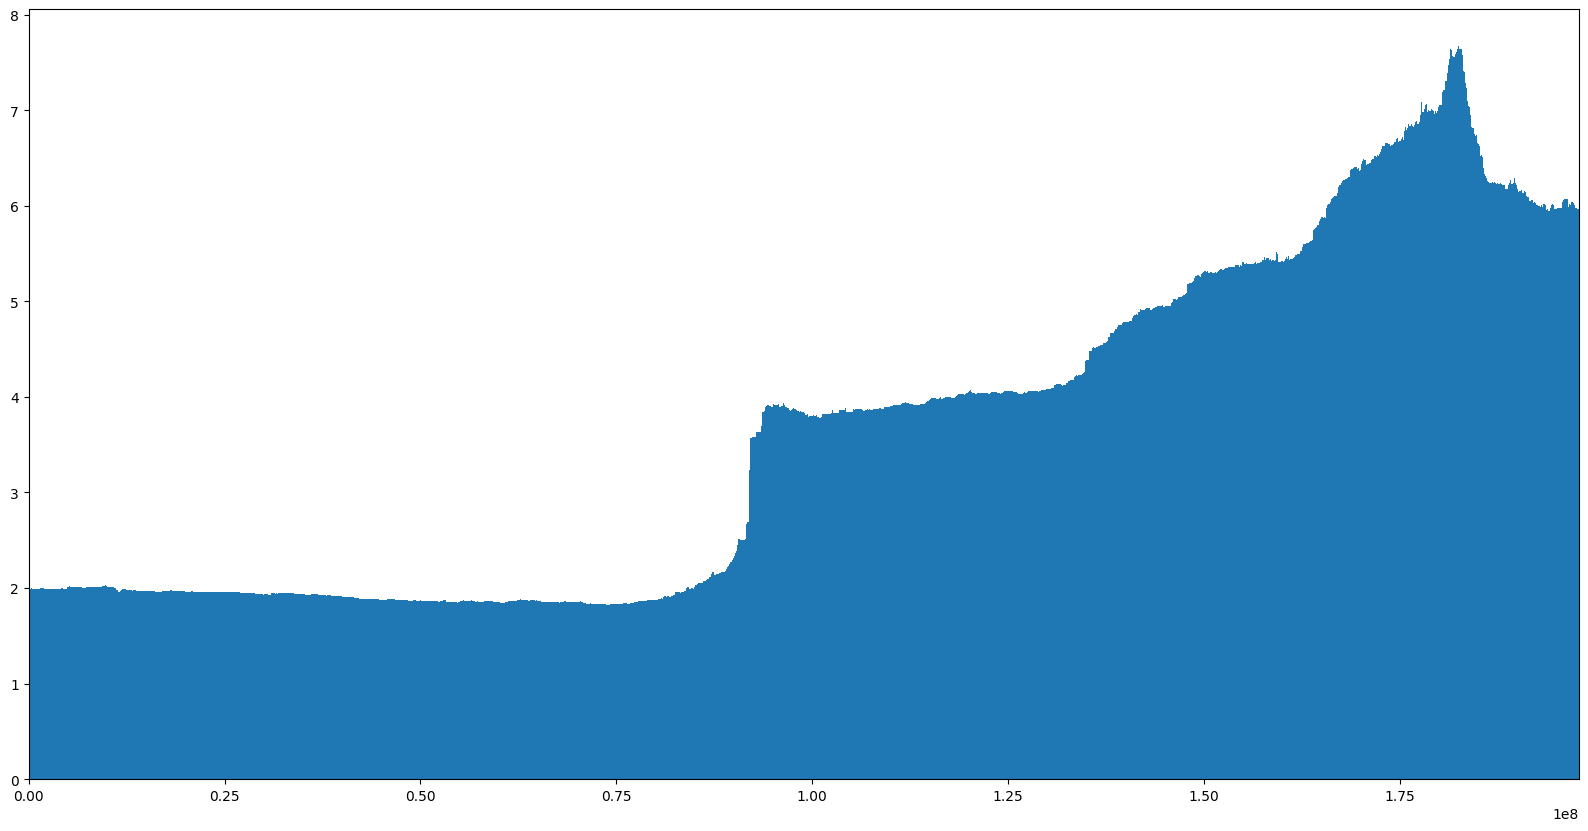

In [83]:
# bar plot groups 
fig, ax = plt.subplots(figsize=(20, 10))

# Create a bar plot
plt.bar(x=groups['start'], height=groups['total_cn'], width=(groups['end'] - groups['start']), align='edge')

# Set the x-axis start to 0
plt.xlim(0, max(counts['end']))
